# LAB 6 — Spectral Clustering i półnadzorowane etykietowanie danych

**Czas:** 90 minut  
**Mini wykład:** ok. 15–20 minut  
**Praca własna:** ok. 70 minut  

## Temat
Wykorzystanie klasteryzacji, szczególnie **Spectral Clustering**, do odgadywania etykiet danych, gdy znany jest tylko niewielki procent klas.

## Cele laboratorium

Po wykonaniu ćwiczenia student powinien umieć:

1. porównać K-Means, DBSCAN i Spectral Clustering,
2. wyjaśnić, dlaczego K-Means zawodzi dla struktur nieliniowych,
3. zbudować graf k-najbliższych sąsiadów,
4. obliczyć Laplasjan grafu i przeanalizować jego wartości własne,
5. zastosować pseudoetykiety do uczenia klasyfikatora,
6. dobrać liczbę klastrów na podstawie wyników eksperymentalnych,
7. sformułować wnioski z eksperymentu.

# Mini wykład

## 1. Problem

W klasycznym uczeniu nadzorowanym zakładamy, że dla każdego obiektu znamy etykietę klasy. W praktyce etykietowanie danych jest kosztowne, czasochłonne i często wymaga eksperta.

W tym laboratorium zakładamy, że znamy tylko około **5% etykiet**, a resztę próbujemy odgadnąć.

## 2. Klasteryzacja

Klasteryzacja grupuje podobne obiekty bez znajomości etykiet. W tym laboratorium porównamy:

- **K-Means** — dobry dla kulistych, wypukłych klastrów,
- **DBSCAN** — dobry dla klastrów gęstościowych i danych z szumem,
- **Spectral Clustering** — dobry dla danych o strukturze grafowej i nieliniowej.

## 3. Graf podobieństwa

Dane można potraktować jako graf:

- wierzchołki = punkty danych,
- krawędzie = podobieństwo lub sąsiedztwo punktów.

Macierz podobieństwa oznaczamy jako:

\[
S
\]

Macierz stopni:

\[
D_{ii} = \sum_j S_{ij}
\]

Laplasjan grafu:

\[
L = D - S
\]

Znormalizowany Laplasjan:

\[
L_{sym} = I - D^{-1/2} S D^{-1/2}
\]

## 4. Idea Spectral Clustering

1. Tworzymy graf podobieństwa.
2. Obliczamy Laplasjan.
3. Wyznaczamy kilka najmniejszych wartości i wektorów własnych.
4. Przenosimy dane do przestrzeni spektralnej.
5. W tej przestrzeni wykonujemy K-Means.

## 5. Pseudoetykiety

Jeżeli znamy tylko część etykiet, możemy:

1. wykonać klasteryzację,
2. sprawdzić, jakie znane etykiety znajdują się w każdym klastrze,
3. nadać całemu klastrowi etykietę większościową,
4. użyć tych pseudoetykiet do trenowania klasyfikatora.

# Przygotowanie środowiska

In [1]:
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter

from sklearn.datasets import make_moons, make_circles, load_digits
from sklearn.cluster import KMeans, DBSCAN, SpectralClustering
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import kneighbors_graph
from sklearn.manifold import spectral_embedding
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.semi_supervised import LabelPropagation, LabelSpreading
from scipy.sparse import csgraph
from scipy.linalg import eigh

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


# Funkcje pomocnicze

Uzupełnij brakujące fragmenty oznaczone jako `TODO`.

In [2]:
def plot_clusters(X, labels, title):
    plt.figure(figsize=(5, 4))
    plt.scatter(X[:, 0], X[:, 1], c=labels, s=20)
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.tight_layout()
    plt.show()


def safe_silhouette(X, labels):
    unique = np.unique(labels)
    if len(unique) < 2 or len(unique) >= len(labels):
        return np.nan
    try:
        return silhouette_score(X, labels)
    except Exception:
        return np.nan


def evaluate_clustering(X, y_true, labels, name):
    return {
        "method": name,
        "ARI": adjusted_rand_score(y_true, labels),  # TODO
        "NMI": normalized_mutual_info_score(y_true, labels),  # TODO
        "Silhouette": safe_silhouette(X, labels),  # TODO
        "n_clusters_found": len(np.unique(labels[labels != -1])),  # TODO
        "n_noise": int(np.sum(labels == -1))  # TODO
    }


def majority_vote_labels(cluster_ids, labeled_indices, y_labeled):
    cluster_to_label = {}

    for c in np.unique(cluster_ids):
        known_labels = []
        # TODO: przejdź po znanych indeksach i zbierz etykiety należące do klastra c
        for i, idx in enumerate(labeled_indices):
            if cluster_ids[idx] == c:
                known_labels.append(y_labeled[i])

        if len(known_labels) > 0:
            cluster_to_label[c] = Counter(known_labels).most_common(1)[0][0]  # TODO
        else:
            cluster_to_label[c] = -1

    pseudo_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    return pseudo_labels, cluster_to_label


def summarize_pseudo_labels(y_true, pseudo_labels):
    mask = pseudo_labels != -1
    coverage = np.mean(mask)  # TODO

    if np.sum(mask) == 0:
        pseudo_acc = np.nan
    else:
        pseudo_acc = accuracy_score(y_true[mask], pseudo_labels[mask])  # TODO

    return {
        "coverage": coverage,
        "pseudo_label_accuracy_on_covered": pseudo_acc,
        "n_covered": int(np.sum(mask)),
        "n_uncovered": int(np.sum(~mask))
    }


# Zadanie 1 — K-Means, DBSCAN i Spectral Clustering na danych nieliniowych

**Czas:** ok. 10–15 minut

## Do wykonania

1. Wygeneruj dane.
2. Przeskaluj dane.
3. Uruchom K-Means, DBSCAN i Spectral Clustering.
4. Zwizualizuj wyniki.
5. Oblicz ARI, NMI i Silhouette Score.

## Pytania

1. Która metoda działa najlepiej dla `make_moons`?
2. Która metoda działa najlepiej dla `make_circles`?
3. Dlaczego K-Means może tu zawodzić?


===== DATASET: MOONS =====


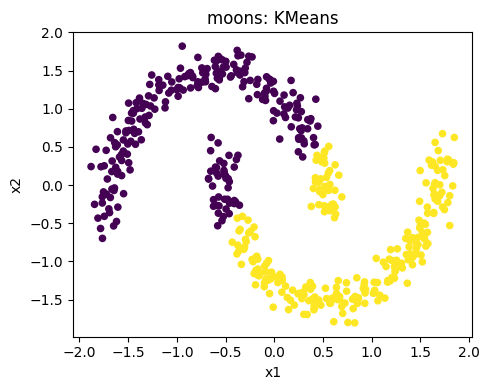

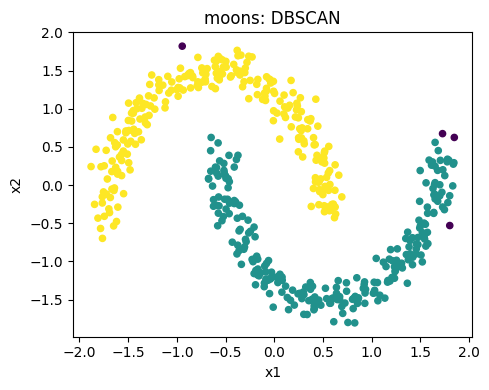

/Users/jkaczmarski/private/university/pum/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


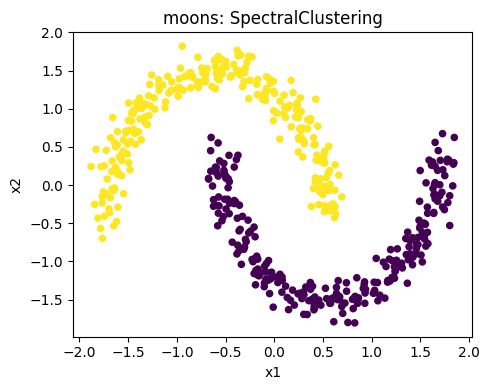


===== DATASET: CIRCLES =====


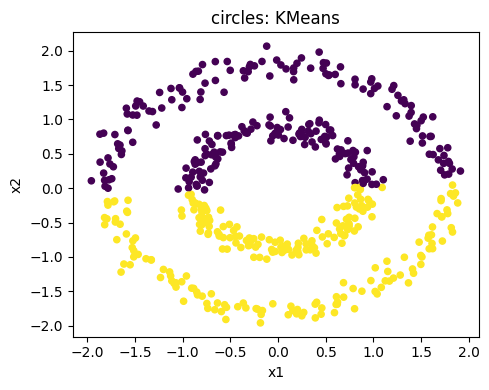

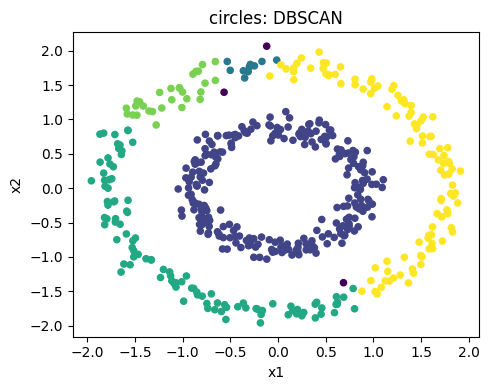

/Users/jkaczmarski/private/university/pum/.venv/lib/python3.13/site-packages/sklearn/manifold/_spectral_embedding.py:324: UserWarning: Graph is not fully connected, spectral embedding may not work as expected.
  warnings.warn(


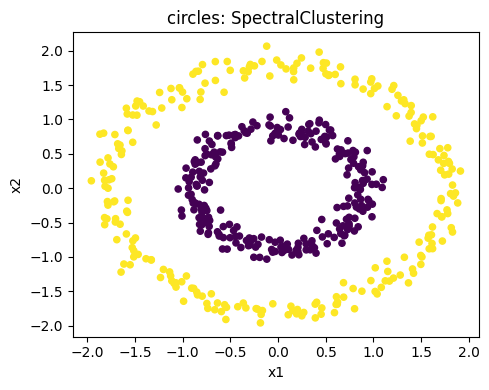

,method,ARI,NMI,Silhouette,n_clusters_found,n_noise
0,moons / KMeans,0.445112,0.351539,0.494355,2,0
1,moons / DBSCAN,0.984080,0.964943,0.296218,2,4
2,moons / SpectralClustering,1.000000,1.000000,0.385733,2,0
3,circles / KMeans,-0.002008,0.000000,0.349732,2,0
4,circles / DBSCAN,0.679825,0.704779,0.118204,5,3
5,circles / SpectralClustering,1.000000,1.000000,0.112602,2,0


In [3]:
datasets = {
    "moons": make_moons(n_samples=500, noise=0.07, random_state=RANDOM_STATE),
    "circles": make_circles(n_samples=500, noise=0.05, factor=0.5, random_state=RANDOM_STATE)
}

all_results = []

for dataset_name, (X_raw, y_true) in datasets.items():
    X = StandardScaler().fit_transform(X_raw)  # TODO

    methods = {
        "KMeans": KMeans(n_clusters=2, random_state=RANDOM_STATE),  # TODO
        "DBSCAN": DBSCAN(eps=0.2, min_samples=5),  # TODO
        "SpectralClustering": SpectralClustering(n_clusters=2, affinity="nearest_neighbors", random_state=RANDOM_STATE)  # TODO
    }

    print(f"\n===== DATASET: {dataset_name.upper()} =====")

    for method_name, model in methods.items():
        labels = model.fit_predict(X)  # TODO
        plot_clusters(X, labels, f"{dataset_name}: {method_name}")

        row = evaluate_clustering(X, y_true, labels, f"{dataset_name} / {method_name}")
        all_results.append(row)

pd.DataFrame(all_results)


## Odpowiedzi do Zadania 1

1. Najlepsza metoda dla `make_moons`:  
   Spectral Clustering - ARI = 1.0, NMI = 1.0 idealne dopasowanie.

2. Najlepsza metoda dla `make_circles`:  
   Spectral Clustering - ARI = 1.0, NMI = 1.0 idealne dopasownaie.

3. Dlaczego K-Means zawodzi?
   K-Means rozdziela przestrzeń liniowo. Dane `make_moons` i `make_circles` mają strukturę nieliniową, której K-Means nie potrafi odwzorować. W przypadku `make_circles` ARI = -0.002, co oznacza wynik losowy.


# Zadanie 2 — Budowa grafu kNN, Laplasjan i wartości własne

**Czas:** ok. 10–15 minut

## Do wykonania

1. Wygeneruj dane `make_moons`.
2. Zbuduj graf k-najbliższych sąsiadów.
3. Oblicz Laplasjan znormalizowany.
4. Wyznacz wartości własne.
5. Narysuj wykres 12 najmniejszych wartości własnych.
6. Spróbuj wskazać potencjalny eigengap.

In [4]:
X_raw, y_true = make_moons(n_samples=300, noise=0.06, random_state=RANDOM_STATE)
X = StandardScaler().fit_transform(X_raw)  # TODO

n_neighbors = 10

A = kneighbors_graph(X, n_neighbors=n_neighbors, mode="connectivity", include_self=False)  # TODO

# symetryzacja grafu
A = (A + A.T)  # TODO
A.data = np.ones_like(A.data)

L = csgraph.laplacian(A, normed=True)  # TODO
L_dense = L.toarray()  # TODO

eigenvalues, eigenvectors = eigh(L_dense)  # TODO

first_k = 12
eig_df = pd.DataFrame({
    "index": np.arange(first_k),
    "eigenvalue": eigenvalues[:first_k]  # TODO
})

eig_df

,index,eigenvalue
0,0,1.617459e-16
1,1,5.737030e-04
2,2,3.144051e-03
3,3,4.879695e-03
4,4,1.157572e-02
5,5,1.322704e-02
6,6,2.606827e-02
7,7,3.026941e-02
8,8,4.424459e-02
9,9,5.329940e-02


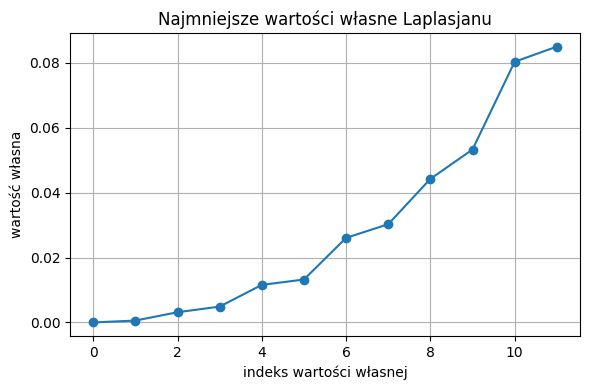

In [5]:
plt.figure(figsize=(6, 4))
plt.plot(eig_df["index"], eig_df["eigenvalue"], marker="o")  # TODO, TODO
plt.title("Najmniejsze wartości własne Laplasjanu")
plt.xlabel("indeks wartości własnej")
plt.ylabel("wartość własna")
plt.grid(True)
plt.tight_layout()
plt.show()

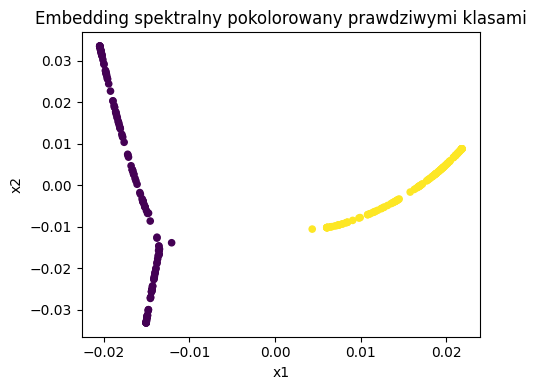

In [6]:
embedding = spectral_embedding(
    A,
    n_components=2,
    random_state=RANDOM_STATE,
    drop_first=True
)

plot_clusters(embedding, y_true, "Embedding spektralny pokolorowany prawdziwymi klasami")

## Odpowiedzi do Zadania 2

1. Czy widać eigengap?  
   Niezbyt wyraźny przy k=2. Wartości własne [0]=0.000, [1]=0.001, [2]=0.003 - różnice są małe i stopniowe. Wyraźniejszy skok pojawia się dopiero przy wyższych indeksach (np. gap[9->10] ≈ 0.027). To może sugerować, że przy tym poziomie szumu granica między klastrami w grafie nie jest ostra.

2. Jak interpretujesz ten wykres?  
   Gdyby dane tworzyły dwie idealnie oddzielone spójne składowe, pierwsza wartość własna byłaby równa 0, a druga też bliska 0, z wyraźnym skokiem przy indeksie 2. Tu obie pierwsze wartości są bliskie zera, ale skok nie jest dramatyczny ze względu na szum i krawędzie łączące obie "księżycowe" grupy. Mimo to wykres sugeruje k=2 jako sensowną liczbę klastrów.

# Zadanie 3 — Półnadzorowane etykietowanie danych Digits

**Czas:** ok. 20 minut

## Do wykonania

1. Wczytaj dane `digits`.
2. Podziel dane na zbiór treningowy i testowy.
3. Pozostaw tylko 5% etykiet treningowych.
4. Wykonaj Spectral Clustering.
5. Nadaj klastrom etykiety metodą większościową.
6. Oblicz jakość pseudoetykiet.

In [7]:
X_digits, y_digits = load_digits(return_X_y=True)  # TODO

X_digits = StandardScaler().fit_transform(X_digits)  # TODO

X_train, X_test, y_train, y_test = train_test_split(
    X_digits,
    y_digits,
    test_size=0.30,
    random_state=RANDOM_STATE,
    stratify=y_digits
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)
print("Liczba klas:", len(np.unique(y_digits)))

Train: (1257, 64)
Test: (540, 64)
Liczba klas: 10


In [8]:
sss = StratifiedShuffleSplit(
    n_splits=1,
    train_size=0.05,
    random_state=RANDOM_STATE
)

idx_labeled, idx_unlabeled = next(sss.split(X_train, y_train))  # TODO

X_labeled = X_train[idx_labeled]  # TODO
y_labeled = y_train[idx_labeled]  # TODO

print("Liczba znanych etykiet:", len(y_labeled))
pd.Series(y_labeled).value_counts().sort_index()

Liczba znanych etykiet: 62


0    6
1    6
2    6
3    7
4    7
5    6
6    6
7    6
8    6
9    6
Name: count, dtype: int64

In [9]:
C = 20

spectral = SpectralClustering(
    n_clusters=C,
    affinity="nearest_neighbors",
    n_neighbors=10,
    random_state=RANDOM_STATE
)

train_clusters = spectral.fit_predict(X_train)  # TODO

pseudo_labels, cluster_to_label = majority_vote_labels(train_clusters, idx_labeled, y_labeled)  # TODO

summary = summarize_pseudo_labels(y_train, pseudo_labels)  # TODO

print("Mapowanie klaster -> etykieta:")
print(cluster_to_label)
print("\nPodsumowanie pseudoetykiet:")
summary

Mapowanie klaster -> etykieta:
{np.int32(0): np.int64(7), np.int32(1): np.int64(0), np.int32(2): np.int64(5), np.int32(3): np.int64(8), np.int32(4): np.int64(2), np.int32(5): np.int64(3), np.int32(6): np.int64(4), np.int32(7): np.int64(4), np.int32(8): np.int64(6), np.int32(9): np.int64(1), np.int32(10): np.int64(7), np.int32(11): np.int64(4), np.int32(12): np.int64(3), np.int32(13): np.int64(9), np.int32(14): np.int64(2), np.int32(15): np.int64(6), np.int32(16): np.int64(5), np.int32(17): np.int64(1), np.int32(18): np.int64(1), np.int32(19): np.int64(4)}

Podsumowanie pseudoetykiet:


{'coverage': np.float64(1.0),
 'pseudo_label_accuracy_on_covered': 0.933969769291965,
 'n_covered': 1257,
 'n_uncovered': 0}

In [10]:
mask = pseudo_labels != -1

print("Raport klasyfikacji pseudoetykiet na danych objętych etykietą:")
print(classification_report(y_train[mask], pseudo_labels[mask], zero_division=0))  # TODO, TODO

cm = confusion_matrix(y_train[mask], pseudo_labels[mask])  # TODO, TODO
pd.DataFrame(cm)

Raport klasyfikacji pseudoetykiet na danych objętych etykietą:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       124
           1       0.90      0.99      0.94       127
           2       1.00      0.90      0.94       124
           3       0.96      0.86      0.91       128
           4       0.86      0.97      0.91       127
           5       0.98      0.98      0.98       127
           6       0.99      1.00      1.00       127
           7       0.97      0.86      0.91       125
           8       0.77      0.98      0.86       122
           9       0.98      0.82      0.89       126

    accuracy                           0.93      1257
   macro avg       0.94      0.93      0.93      1257
weighted avg       0.94      0.93      0.93      1257



,0,1,2,3,4,5,6,7,8,9
0,124,0,0,0,0,0,0,0,0,0
1,0,126,0,0,0,0,0,0,1,0
2,0,4,111,1,0,0,0,0,8,0
3,0,0,0,110,0,0,1,2,15,0
4,0,0,0,0,123,1,0,1,2,0
5,0,0,0,1,0,124,0,0,0,2
6,0,0,0,0,0,0,127,0,0,0
7,0,0,0,0,17,0,0,107,1,0
8,0,2,0,1,0,0,0,0,119,0
9,0,8,0,2,3,2,0,0,8,103


## Odpowiedzi do Zadania 3

1. Ile danych otrzymało pseudoetykiety?  
   Wszystkie 1257 przykładów treningowych (coverage = 100%). Każdy z 20 klastrów miał co najmniej jedną ze znanych 62 etykiet, więc żaden punkt nie wyszedł bez pseudoetykiety.

2. Jaka była trafność pseudoetykiet?  
    ~93.4% - bardzo dobry wynik, biorąc pod uwagę że mieliśmy tylko 62 prawdziwe etykiety (5% danych treningowych).

3. Które klasy były najtrudniejsze?  
   - Klasa 8 - najniższa precision = 0.77, czyli dużo innych cyfr było błędnie wrzucanych do jej klastrów
   - Klasa 9 - najniższy recall = 0.82, czyli część dziewiątek trafiała do klastrów z inną etykietą


# Zadanie 4 — Klasyfikator trenowany na pseudoetykietach

**Czas:** ok. 10 minut

Naucz Random Forest na danych z pseudoetykietami i przetestuj go na zbiorze testowym.

In [11]:
rf_pseudo = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_pseudo.fit(X_train[mask], pseudo_labels[mask])  # TODO, TODO
y_pred_rf_pseudo = rf_pseudo.predict(X_test)  # TODO

acc_rf_pseudo = accuracy_score(y_test, y_pred_rf_pseudo)  # TODO

print("Accuracy Random Forest trenowanego na pseudoetykietach:", acc_rf_pseudo)
print(classification_report(y_test, y_pred_rf_pseudo, zero_division=0))

Accuracy Random Forest trenowanego na pseudoetykietach: 0.9259259259259259
              precision    recall  f1-score   support

           0       1.00      0.96      0.98        54
           1       0.84      0.98      0.91        55
           2       1.00      0.91      0.95        53
           3       0.96      0.91      0.93        55
           4       0.88      0.98      0.93        54
           5       0.98      0.98      0.98        55
           6       1.00      0.98      0.99        54
           7       0.98      0.93      0.95        54
           8       0.72      0.90      0.80        52
           9       0.97      0.72      0.83        54

    accuracy                           0.93       540
   macro avg       0.93      0.93      0.93       540
weighted avg       0.94      0.93      0.93       540



# Zadanie 5 — Wpływ liczby klastrów C

**Czas:** ok. 15 minut

Testujemy C = 10, 15, 20, 25, 30, 40.

Dla każdego C oblicz: coverage, accuracy pseudoetykiet i accuracy klasyfikatora.

In [12]:
C_values = [10, 15, 20, 25, 30, 40]

experiment_results = []

for C in C_values:
    spectral = SpectralClustering(
        n_clusters=C,
        affinity="nearest_neighbors",
        n_neighbors=10,
        random_state=RANDOM_STATE
    )

    clusters = spectral.fit_predict(X_train)  # TODO

    pseudo_labels_C, cluster_to_label_C = majority_vote_labels(clusters, idx_labeled, y_labeled)  # TODO

    pseudo_summary = summarize_pseudo_labels(y_train, pseudo_labels_C)  # TODO

    mask_C = pseudo_labels_C != -1  # TODO

    rf = RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE
    )

    rf.fit(X_train[mask_C], pseudo_labels_C[mask_C])  # TODO, TODO
    pred = rf.predict(X_test)  # TODO
    test_acc = accuracy_score(y_test, pred)  # TODO

    experiment_results.append({
        "C": C,
        "coverage": pseudo_summary["coverage"],  # TODO
        "pseudo_label_accuracy": pseudo_summary["pseudo_label_accuracy_on_covered"],  # TODO
        "test_accuracy_RF": test_acc,  # TODO
        "n_covered": pseudo_summary["n_covered"],  # TODO
        "n_uncovered": pseudo_summary["n_uncovered"]  # TODO
    })

results_df = pd.DataFrame(experiment_results)
results_df

,C,coverage,pseudo_label_accuracy,test_accuracy_RF,n_covered,n_uncovered
0,10,1.000000,0.750199,0.729630,1257,0
1,15,1.000000,0.922832,0.905556,1257,0
2,20,1.000000,0.933970,0.925926,1257,0
3,25,0.899761,0.916888,0.909259,1131,126
4,30,0.883055,0.907207,0.907407,1110,147
5,40,0.854415,0.932030,0.914815,1074,183


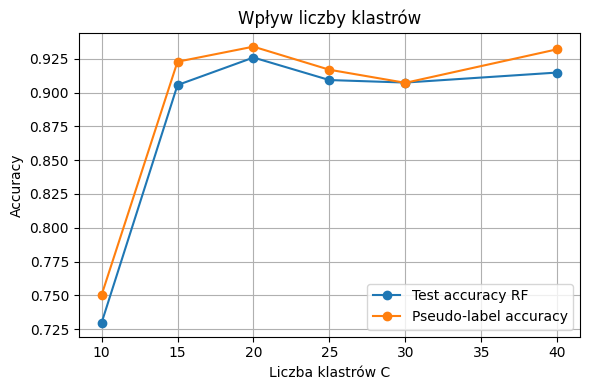

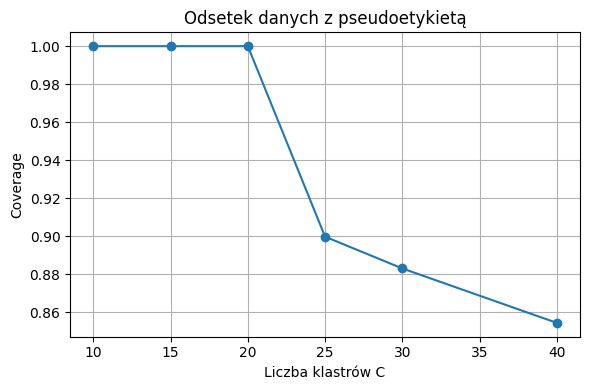

In [13]:
plt.figure(figsize=(6, 4))
plt.plot(results_df["C"], results_df["test_accuracy_RF"], marker="o", label="Test accuracy RF")
plt.plot(results_df["C"], results_df["pseudo_label_accuracy"], marker="o", label="Pseudo-label accuracy")
plt.xlabel("Liczba klastrów C")
plt.ylabel("Accuracy")
plt.title("Wpływ liczby klastrów")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(results_df["C"], results_df["coverage"], marker="o")
plt.xlabel("Liczba klastrów C")
plt.ylabel("Coverage")
plt.title("Odsetek danych z pseudoetykietą")
plt.grid(True)
plt.tight_layout()
plt.show()

## Odpowiedzi do Zadania 5

1. Najlepsze C:  
   20 - najwyższa test accuracy (92.6%) przy pełnym coverage.

2. Czy najlepsze C = liczba klas?  
    Nie. Mamy 10 klas, a najlepsze C=20. Większa liczba klastrów pozwala uchwycić wewnętrzne zróżnicowanie klas - ta sama cyfra może być pisana różnie, więc warto ją rozbić na kilka klastrów.

3. Jak interpretujesz wykresy?  
   - Od C=10 do C=20 rośnie i accuracy i coverage — klastry są coraz bardziej jednorodne
   - Od C=25 wzwyż coverage zaczyna spadać (część klastrów nie ma żadnej ze znanych 62 etykiet → dostaje -1), co zmniejsza zbiór treningowy RF
   - Pomimo że pseudo_acc dla C=40 jest wysoka (93.2%), test accuracy jest niższe niż C=20 — bo RF trenuje na mniejszej liczbie danych (1074 vs 1257)

# Zadanie 6 — Porównanie z uczeniem nadzorowanym tylko na 5% etykiet

**Czas:** ok. 10 minut

Naucz Random Forest i MLP tylko na 5% prawdziwych etykiet. Porównaj z metodą wykorzystującą pseudoetykiety.

In [14]:
rf_supervised_small = RandomForestClassifier(
    n_estimators=300,
    random_state=RANDOM_STATE
)

rf_supervised_small.fit(X_labeled, y_labeled)  # TODO, TODO
pred_rf_small = rf_supervised_small.predict(X_test)  # TODO

acc_rf_small = accuracy_score(y_test, pred_rf_small)  # TODO

mlp_supervised_small = MLPClassifier(
    hidden_layer_sizes=(100,),
    max_iter=600,
    random_state=RANDOM_STATE
)

mlp_supervised_small.fit(X_labeled, y_labeled)  # TODO, TODO
pred_mlp_small = mlp_supervised_small.predict(X_test)  # TODO

acc_mlp_small = accuracy_score(y_test, pred_mlp_small)  # TODO

comparison_df = pd.DataFrame([
    {
        "method": "Random Forest only 5% true labels",
        "test_accuracy": acc_rf_small  # TODO
    },
    {
        "method": "MLP only 5% true labels",
        "test_accuracy": acc_mlp_small  # TODO
    },
    {
        "method": "Spectral Clustering + pseudo-labels + RF",
        "test_accuracy": acc_rf_pseudo  # TODO
    }
])

comparison_df

,method,test_accuracy
0,Random Forest only 5% true labels,0.837037
1,MLP only 5% true labels,0.837037
2,Spectral Clustering + pseudo-labels + RF,0.925926


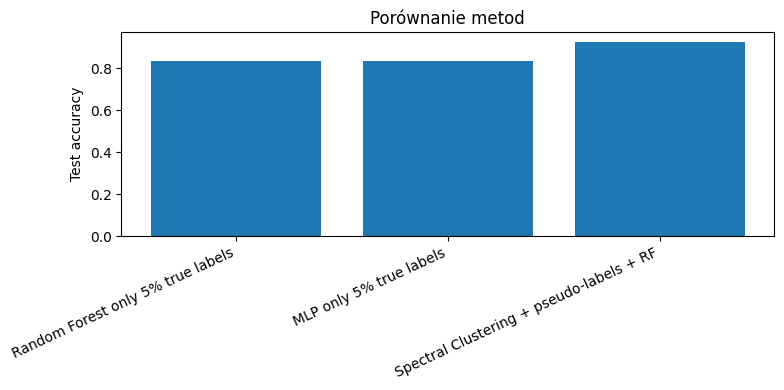

In [15]:
plt.figure(figsize=(8, 4))
plt.bar(comparison_df["method"], comparison_df["test_accuracy"])
plt.ylabel("Test accuracy")
plt.title("Porównanie metod")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

## Odpowiedzi do Zadania 6

1. Czy pseudoetykiety poprawiły wynik?  
   Tak, znacząco. RF trenowany na pseudoetykietach (92.6%) bije oba modele trenowane tylko na 5% prawdziwych etykiet (83.7%) o prawie 9 punktów procentowych. Mając dostęp do ~1200 przykładów zamiast 62, nawet z zaszumionymi etykietami  model działa dużo lepiej.

2. Który klasyfikator był najlepszy?  
   RF z pseudoetykietami. Ciekawe że RF i MLP na czystych 5% dały identyczny wynik (83.7%) — przy tak małym zbiorze treningowym (62 przykłady) architektura modelu nie ma znaczenia, bo bottleneck to ilość danych.

3. Jakie ryzyko niesie używanie pseudoetykiet?  
   Błędy w pseudoetykietach propagują się do klasyfikatora — jeśli klaster jest niejednorodny i dostanie złą etykietę większościową, RF uczy się na złych danych. Tu ~6.6% pseudoetykiet było błędnych, co finalnie obniżyło accuracy względem modelu trenowanego na 100% prawdziwych etykiet.

# Zadanie 7 — Metody półnadzorowane ze scikit-learn

**Zadanie dodatkowe lub dla szybszych grup**

Porównaj swoje podejście z gotowymi metodami `LabelPropagation` i `LabelSpreading`.

In [16]:
semi_labels = np.full_like(y_train, fill_value=-1)
semi_labels[idx_labeled] = y_train[idx_labeled]

lp = LabelPropagation(kernel="knn", n_neighbors=10, max_iter=1000)
lp.fit(X_train, semi_labels)  # TODO, TODO
pred_lp = lp.predict(X_test)  # TODO
acc_lp = accuracy_score(y_test, pred_lp)  # TODO

ls = LabelSpreading(kernel="knn", n_neighbors=10, alpha=0.2, max_iter=1000)
ls.fit(X_train, semi_labels)  # TODO, TODO
pred_ls = ls.predict(X_test)  # TODO
acc_ls = accuracy_score(y_test, pred_ls)  # TODO

semi_df = pd.DataFrame([
    {"method": "LabelPropagation", "test_accuracy": acc_lp},  # TODO
    {"method": "LabelSpreading", "test_accuracy": acc_ls},  # TODO
    {"method": "Best Spectral pseudo-labels + RF", "test_accuracy": acc_rf_pseudo},  # TODO
    {"method": "RF only 5% labels", "test_accuracy": acc_rf_small},  # TODO
    {"method": "MLP only 5% labels", "test_accuracy": acc_mlp_small}  # TODO
])

semi_df

/Users/jkaczmarski/private/university/pum/.venv/lib/python3.13/site-packages/sklearn/semi_supervised/_label_propagation.py:324: ConvergenceWarning: max_iter=1000 was reached without convergence.
  warnings.warn(


,method,test_accuracy
0,LabelPropagation,0.874074
1,LabelSpreading,0.920370
2,Best Spectral pseudo-labels + RF,0.925926
3,RF only 5% labels,0.837037
4,MLP only 5% labels,0.837037


# Wnioski końcowe

## 1. Który algorytm klasteryzacji był najlepszy dla danych nieliniowych?

Spectral Clustering — uzyskał ARI=1.0 dla make_moons i make_circles, podczas gdy K-Means osiągnął ARI bliskie zeru. K-Means nie radzi sobie z nieliniowymi strukturami, bo rozdziela przestrzeń liniowo.

![K-Means vs Spectral Clustering](img/kmeans_vs_spectral.png)

## 2. Czy liczba klastrów powinna być równa liczbie klas?

Nie — w zadaniu 5 najlepsze wyniki dało C=20 przy 10 klasach. Więcej klastrów pozwala uchwycić wewnętrzne zróżnicowanie klas (np. różne style pisania tej samej cyfry).

## 3. Jak zmienia się skuteczność wraz ze wzrostem liczby klastrów C?

Do C=20 rośnie zarówno accuracy jak i coverage. Powyżej C=20 coverage zaczyna spadać, bo część klastrów nie dostaje żadnej ze znanych etykiet i punkty pozostają bez pseudoetykiety, co zmniejsza zbiór treningowy klasyfikatora.

![Accuracy i coverage vs C](img/accuracy_vs_C.png)

## 4. Czy pseudoetykiety poprawiają skuteczność klasyfikatora?

Tak — RF z pseudoetykietami osiągnął 92.6% vs 83.7% dla RF trenowanego tylko na 5% prawdziwych etykiet. Nawet zaszumione etykiety na dużym zbiorze dają lepszy wynik niż czyste etykiety na małym zbiorze.

## 5. Jakie są główne ograniczenia Spectral Clustering?

Wysoka złożoność obliczeniowa — wymaga wyznaczenia wartości własnych macierzy n×n, co nie skaluje się dobrze dla dużych zbiorów. Ponadto wymaga z góry podanej liczby klastrów C i jest wrażliwy na wybór parametrów grafu (np. n_neighbors).

![Wartości własne Laplasjanu](img/eigenvalues.png)

## 6. W jakich problemach praktycznych można wykorzystać takie podejście?

Wszędzie tam, gdzie etykietowanie jest kosztowne — np. medyczne obrazowanie (diagnozowanie wymaga eksperta), analiza tekstu, rozpoznawanie mowy. Wystarczy ręcznie oznaczyć kilka procent danych, resztę można pseudoetykietować klasteryzacją.

## 7. Najważniejszy wniosek z laboratorium

Klasteryzacja spektralna umożliwia skuteczne półnadzorowane uczenie — przy zaledwie 5% etykiet udało się osiągnąć 92.6% accuracy na zbiorze digits. Kluczem jest dobór liczby klastrów większej niż liczba klas oraz zapewnienie, że każdy klaster ma co najmniej jedną znaną etykietę.